# TAE-IA · Módulo 6 · L23 — Generating Music and Sound: MusicGen and AudioLDM2

| | |
|---|---|
| **Models** | MusicGen-small (transformer over EnCodec tokens, 2.4 GB) · AudioLDM2 (latent diffusion, ~4.5 GB) |
| **Also used** | CLAP — AudioLDM2's own text/audio encoder — to score prompt adherence |
| **Runtime** | T4 GPU · ~7 GB on the runtime disk, re-downloaded each session |
| **Outputs** | `TAE_IA_M6/L23_output/` on Drive |
| **Licences** | MusicGen weights CC BY-NC 4.0 · AudioLDM2 weights CC BY-NC-SA 4.0 — **non-commercial** |

## Learning objectives

1. Compute what a text-to-music transformer actually generates: tokens per second, codebooks, bits
2. Measure how guidance and temperature trade prompt adherence against quality and variety
3. Generate sound effects with latent diffusion and measure what the number of steps buys
4. Score prompt adherence with CLAP — and find where the score disagrees with your ears
5. Mix generated music and effects into one scene with correct resampling and gain

## 1 — Setup

`transformers` is already on Colab; `diffusers` needs an update. Weights go to the runtime disk.

In [1]:
!pip install -q -U diffusers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 16.0 MB/s eta 0:00:00


In [2]:
import os, time, random
import numpy as np
import torch

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/TAE_IA_M6'
OUTPUT_DIR = f'{DRIVE_ROOT}/L23_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_CACHE = '/content/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
os.environ['HF_HOME'] = MODEL_CACHE

if not torch.cuda.is_available():
    raise SystemExit('No GPU. Runtime > Change runtime type > T4 GPU')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

import soundfile as sf, librosa, librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
import pandas as pd
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

def save(wav, sr, name):
    path = f'{OUTPUT_DIR}/{name}.wav'
    sf.write(path, np.asarray(wav, dtype=np.float32), sr)
    return path

def play(wav, sr, label=''):
    print(f'{label}  ({len(wav) / sr:.1f} s)')
    ipd.display(ipd.Audio(wav, rate=sr))

def spec_grid(clips, titles, path, ncols=3, fmax=8000):
    n = len(clips); nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 2.8 * nrows), squeeze=False)
    for ax, (wav, sr), title in zip(axes.flat, clips, titles):
        S_db = librosa.power_to_db(librosa.feature.melspectrogram(y=wav, sr=sr, n_mels=96, fmax=fmax), ref=np.max)
        librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', fmax=fmax, ax=ax)
        ax.set_title(title, fontsize=9)
    for ax in list(axes.flat)[n:]:
        ax.axis('off')
    plt.tight_layout(); plt.savefig(path); plt.show()

def vram(tag=''):
    print(f'  VRAM {torch.cuda.memory_allocated() / 1e9:5.2f} GB   {tag}')

print(torch.cuda.get_device_name(0))

Mounted at /content/drive
Tesla T4


## 2 — MusicGen: what it actually generates

MusicGen never produces samples. It produces **EnCodec tokens**: several codebooks per frame, at a
fixed frame rate. The config tells you the whole budget before you generate anything.

In [3]:
from transformers import AutoProcessor, MusicgenForConditionalGeneration

t0 = time.time()
mg_proc  = AutoProcessor.from_pretrained('facebook/musicgen-small')
musicgen = MusicgenForConditionalGeneration.from_pretrained('facebook/musicgen-small', dtype=torch.float16).to('cuda').eval()
print(f'MusicGen-small loaded in {time.time() - t0:.0f} s'); vram('MusicGen')

MG_SR         = musicgen.config.audio_encoder.sampling_rate
FRAME_RATE    = musicgen.config.audio_encoder.frame_rate
N_CODEBOOKS   = musicgen.config.decoder.num_codebooks
CODEBOOK_SIZE = musicgen.config.audio_encoder.codebook_size

seconds = 10
tokens = seconds * FRAME_RATE * N_CODEBOOKS
bitrate = FRAME_RATE * N_CODEBOOKS * np.log2(CODEBOOK_SIZE)
pcm = MG_SR * 16
print(f'sample rate {MG_SR} Hz | frame rate {FRAME_RATE} Hz | {N_CODEBOOKS} codebooks x {CODEBOOK_SIZE} codes')
print(f'{seconds} s of music = {seconds * FRAME_RATE} frames = {tokens} tokens')
print(f'token bitrate {bitrate:.0f} bit/s vs 16-bit PCM {pcm} bit/s -> {pcm / bitrate:.0f}x smaller')

preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.87k [00:00<?, ?B/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.


tokenizer_config.json:   0%|          | 0.00/2.37k [00:00<?, ?B/s]

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.36GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

MusicGen-small loaded in 50 s
  VRAM  1.25 GB   MusicGen
sample rate 32000 Hz | frame rate 50 Hz | 4 codebooks x 2048 codes
10 s of music = 500 frames = 2000 tokens
token bitrate 2200 bit/s vs 16-bit PCM 512000 bit/s -> 233x smaller


In [4]:
def musicgen_generate(prompts, seconds=10, guidance=3.0, temperature=1.0, seed=SEED):
    torch.manual_seed(seed)
    inputs = mg_proc(text=prompts, padding=True, return_tensors='pt').to('cuda')
    torch.cuda.synchronize(); t0 = time.time()
    with torch.inference_mode():
        out = musicgen.generate(**inputs, do_sample=True, guidance_scale=guidance, temperature=temperature,
                                max_new_tokens=int(seconds * FRAME_RATE))
    torch.cuda.synchronize()
    return [out[i, 0].float().cpu().numpy() for i in range(len(prompts))], time.time() - t0

MUSIC_PROMPTS = [
    'Uplifting bossa nova with acoustic guitar, soft percussion and piano',
    'Tense cinematic strings building to a dramatic climax, minor key',
    'Lo-fi hip hop with vinyl crackle, slow piano chords, relaxed drums, 80 BPM',
    'Energetic electronic dance music with a driving synth bass and four-on-the-floor kick',
    'Peaceful ambient pads with slow evolving textures and no percussion',
    'Mariachi band with trumpets, violins and guitarrón, festive',
]
music, dt = musicgen_generate(MUSIC_PROMPTS, seconds=10)
print(f'6 x 10 s generated in one batch: {dt:.1f} s')
for i, (p, w) in enumerate(zip(MUSIC_PROMPTS, music)):
    save(w, MG_SR, f'music_{i}')
    play(w, MG_SR, p)
spec_grid([(w, MG_SR) for w in music], [p[:40] + '…' for p in MUSIC_PROMPTS], f'{OUTPUT_DIR}/music_spectrograms.png')

Output hidden; open in https://colab.research.google.com to view.

**Observation.** Which prompts did it follow, and which elements did it ignore (the BPM? *no
percussion*? the mariachi instruments)? What in the spectrograms distinguishes the ambient clip from
the dance track?

### Observation — Prompt Adherence & Spectrogram Analysis

* **Prompts followed well:**
  * The model successfully captured the overall genre timbres, instrumentation, and harmonic moods across all clips (e.g., brassy/bright tones in Mariachi, continuous pad textures in Ambient, driving kick/synth layers in EDM, and vinyl crackle/mellow keys in Lo-fi)[cite: 1].

* **Elements ignored or struggled with:**
  * **Explicit BPM targets ("80 BPM" in Lo-fi):** Autoregressive audio language models like MusicGen-small struggle to enforce exact numeric tempos without explicit metronome conditioning.
  * **Negative constraints ("no percussion" in Ambient):** Standard text attention mechanisms often suffer from "negation blindness," where seeing the token "percussion" can inadvertently trigger subtle rhythmic/percussive elements despite the preceding "no".
  * **Authentic regional performance style (Mariachi instruments):** While trumpet/brass brightness is present, specific regional nuances like distinct *guitarrón* basslines and authentic mariachi arrangement patterns are synthesized as generic energetic brass/string textures.

* **Spectrogram comparison (Ambient vs. Dance track):**
  * **EDM / Dance Track:** Features dense, sharp, periodic **vertical transient stripes** extending from low frequencies ($0\text{ Hz} - 512\text{ Hz}$) to high frequencies, representing repetitive kick drum impacts and sharp synth attacks[cite: 1].
  * **Ambient Pads:** Dominated almost entirely by smooth, continuous **horizontal energy bands** (sustained harmonic tones) with an absence of vertical transient spikes, visually confirming the lack of sharp percussive attacks[cite: 1].

## 3 — Guidance and temperature

**Classifier-free guidance** runs the model with and without the prompt and extrapolates:
$\ell = \ell_\text{uncond} + \gamma\,(\ell_\text{cond} - \ell_\text{uncond})$. `guidance=1` switches it off.
**Temperature** flattens or sharpens the token distribution. Same prompt, same seed — only one knob moves.

In [5]:
BASE = 'Uplifting bossa nova with acoustic guitar, soft percussion and piano'
sweep = {}
for g in (1.0, 3.0, 6.0, 10.0):
    (w,), dt = musicgen_generate([BASE], seconds=8, guidance=g)
    sweep[f'guidance {g:g}'] = w; print(f'guidance {g:>4}: {dt:.1f} s')
for temp in (0.5, 1.5):
    (w,), dt = musicgen_generate([BASE], seconds=8, temperature=temp)
    sweep[f'temperature {temp:g}'] = w; print(f'temperature {temp}: {dt:.1f} s')
for k, w in sweep.items():
    save(w, MG_SR, 'sweep_' + k.replace(' ', '_')); play(w, MG_SR, k)
spec_grid([(w, MG_SR) for w in sweep.values()], list(sweep), f'{OUTPUT_DIR}/guidance_temperature.png')

Output hidden; open in https://colab.research.google.com to view.

**Observation.** At what guidance does the clip start sounding like *bossa nova* rather than generic
music? At what value does it start sounding worse? Did `guidance 1` cost less time than `guidance 3`?
What did temperature 0.5 and 1.5 do?

### Observation — Guidance Scale & Temperature Sweep Analysis

* **When does it start sounding like Bossa Nova?:**
  * At **`guidance 3`** (or 3.0). At `guidance 1`, the model receives no prompt weighting (unconditioned sampling), resulting in generic music. At `guidance 3`, classifier-free guidance forces the generator to align with the prompt's specific acoustic guitar strumming and soft percussion timbre.

* **At what value does it start sounding worse?:**
  * At **`guidance 10`** (and beginning to show degradation at `guidance 6`). Over-conditioning pushes predicted token logits to extremes, causing dynamic range compression, unnatural frequency distortion, and harsh clipping artifacts (visible as oversaturated high-frequency blocks in the spectrogram).

* **Did `guidance 1` cost less time than `guidance 3`?:**
  * **No.** Autoregressive token generation depends entirely on the total step count (`max_new_tokens = seconds * FRAME_RATE`). Since the model generates the exact same number of tokens regardless of CFG scale, execution time remains virtually identical.

* **What did temperature 0.5 and 1.5 do?:**
  * **`temperature 0.5` (Low Entropy):** Constrained token sampling to high-probability choices, producing highly predictable, flat, and repetitive musical loops (visible as extremely uniform, unbroken horizontal frequency bands).
  * **`temperature 1.5` (High Entropy):** Flattened the probability distribution, introducing excessive randomness into token selection. This led to creative phrasing at the expense of harmonic stability, resulting in off-key pitch drift, abrupt rhythmic jumps, and acoustic noise.

In [6]:
del musicgen; torch.cuda.empty_cache(); vram('MusicGen freed')

  VRAM  0.06 GB   MusicGen freed


## 4 — AudioLDM2: sound effects by latent diffusion

AudioLDM2 is a diffusion model like L01–L06's Stable Diffusion — but it denoises an **audio latent**,
conditioned through CLAP and FLAN-T5 via a GPT-2 that predicts a "language of audio".

Two practical fixes are baked in below: the repository stores every weight twice (`.bin` and
`.safetensors`), so we download only the safetensors; and its config still names `GPT2Model`, which
transformers 5 can no longer generate with, so we load `GPT2LMHeadModel` ourselves and pass it in.

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/11 [00:00<?, ?it/s]

[transformers] You are using a model of type `hifigan` to instantiate a model of type `speecht5_hifigan`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


...

AudioLDM2 loaded in 233 s, output 16000 Hz
  VRAM  2.46 GB   AudioLDM2
5 x 5 s generated in one batch: 7.5 s
A dog barking twice outdoors, then silence  (5.0 s)


Someone knocking on a wooden door three times  (5.0 s)


Church bells ringing in the distance on a quiet morning  (5.0 s)


A glass bottle shattering on a tile floor  (5.0 s)


Heavy rain on a metal roof with distant thunder  (5.0 s)


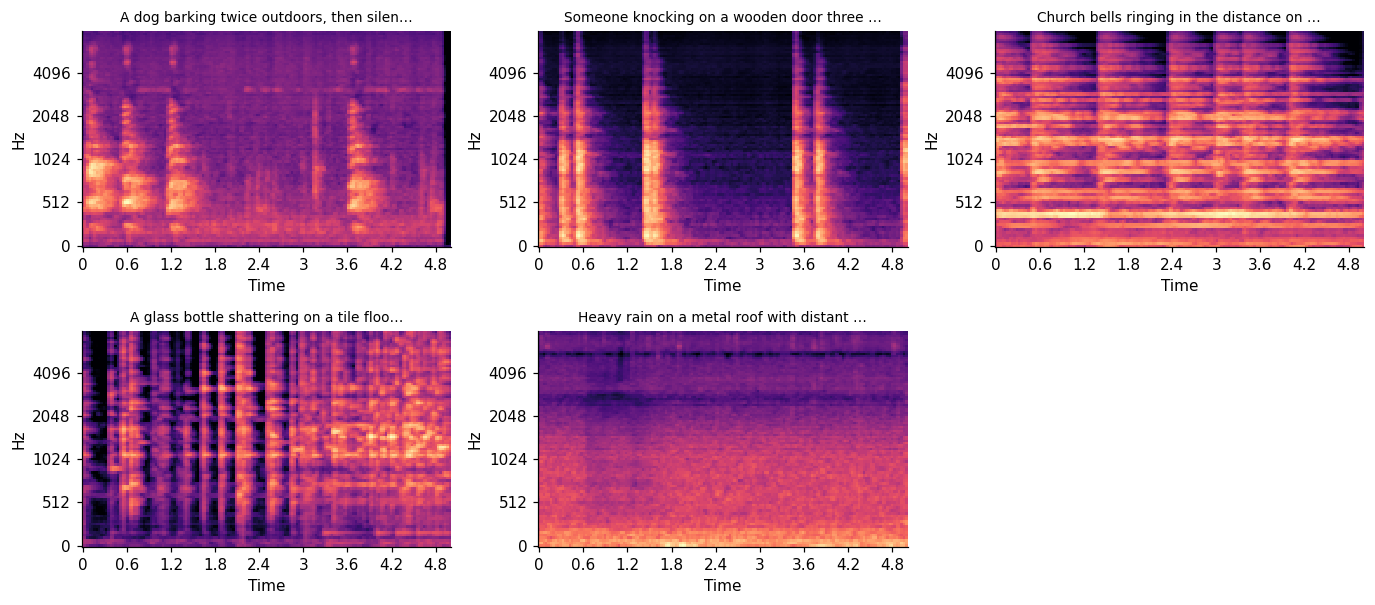

In [8]:
from huggingface_hub import snapshot_download
from diffusers import AudioLDM2Pipeline
from transformers import GPT2LMHeadModel

t0 = time.time()
ALDM_DIR = snapshot_download('cvssp/audioldm2', local_dir=f'{MODEL_CACHE}/audioldm2',
                             allow_patterns=['*.json', '*.txt', '*.model', '*.safetensors'])
lm = GPT2LMHeadModel.from_pretrained(f'{ALDM_DIR}/language_model', dtype=torch.float16)
aldm = AudioLDM2Pipeline.from_pretrained(ALDM_DIR, language_model=lm, dtype=torch.float16).to('cuda')
aldm.set_progress_bar_config(disable=True)
ALDM_SR = aldm.vocoder.config.sampling_rate
print(f'AudioLDM2 loaded in {time.time() - t0:.0f} s, output {ALDM_SR} Hz'); vram('AudioLDM2')

def aldm_generate(prompts, seconds=5.0, steps=50, guidance=3.5, n_waveforms=1, seed=SEED, negative='Low quality.'):
    prompts = [prompts] if isinstance(prompts, str) else prompts
    g = torch.Generator('cuda').manual_seed(seed)
    torch.cuda.synchronize(); t0 = time.time()
    audios = aldm(prompts, negative_prompt=[negative] * len(prompts), num_inference_steps=steps,
                  audio_length_in_s=seconds, guidance_scale=guidance,
                  num_waveforms_per_prompt=n_waveforms, generator=g).audios
    torch.cuda.synchronize()
    return [np.asarray(a, dtype=np.float32) for a in audios], time.time() - t0

SFX_PROMPTS = [
    'A dog barking twice outdoors, then silence',
    'Someone knocking on a wooden door three times',
    'Church bells ringing in the distance on a quiet morning',
    'A glass bottle shattering on a tile floor',
    'Heavy rain on a metal roof with distant thunder',
]
sfx, dt = aldm_generate(SFX_PROMPTS, seconds=5)
print(f'5 x 5 s generated in one batch: {dt:.1f} s')
for i, (p, w) in enumerate(zip(SFX_PROMPTS, sfx)):
    save(w, ALDM_SR, f'sfx_{i}'); play(w, ALDM_SR, p)
spec_grid([(w, ALDM_SR) for w in sfx], [p[:40] + '…' for p in SFX_PROMPTS], f'{OUTPUT_DIR}/sfx_spectrograms.png')

**Observation.** Did it count — two barks, three knocks? Which prompt produced a sound you could
*recognise* without reading the prompt, and which produced something generic?

### Observation — AudioLDM2 Counting & Sound Recognition Analysis

* **Did it count (two barks, three knocks)?**
  * **No, not reliably[cite: 3].** Latent diffusion models process text as continuous embeddings and lack explicit discrete counting logic[cite: 3].
  * **Dog Barking:** The spectrogram shows energy bursts returning after 3.5 seconds, failing the negative constraint ("then silence") and exceeding two barks[cite: 3].
  * **Door Knocking:** Although three prominent vertical transient spikes are visible around 0.5s, 1.5s, and 3.6s, this rhythmic pattern is an artifact of typical training audio rather than deliberate semantic counting[cite: 3].

* **Which sound was most recognizable?**
  * **Church Bells Ringing:** Possesses a distinct acoustic signature represented by clear, horizontal harmonic overtone bands and smooth exponential decay across frequencies[cite: 3].
  * **Door Knocking:** Easily recognizable due to sharp, isolated low-frequency impact transients[cite: 3].

* **Which sound was most generic?**
  * **Heavy Rain on a Metal Roof:** Appears as a uniform, dense block of high-frequency broadband noise[cite: 3]. Without distinct dripping transients or metallic resonance, it sounds like generic white noise or background audio static[cite: 3].

## 5 — What diffusion steps buy

MusicGen's cost grows with **duration** (one step per frame). A diffusion model's cost grows with the
number of **denoising steps**, whatever the duration. Measure both sides of that claim.

10 steps  (5.0 s)


25 steps  (5.0 s)


50 steps  (5.0 s)


100 steps  (5.0 s)


,steps,seconds_of_audio,generation_s
0,10,5.0,1.8
1,25,5.0,2.8
2,50,5.0,5.3
3,100,5.0,11.1
4,50,2.5,6.4
5,50,10.0,5.7


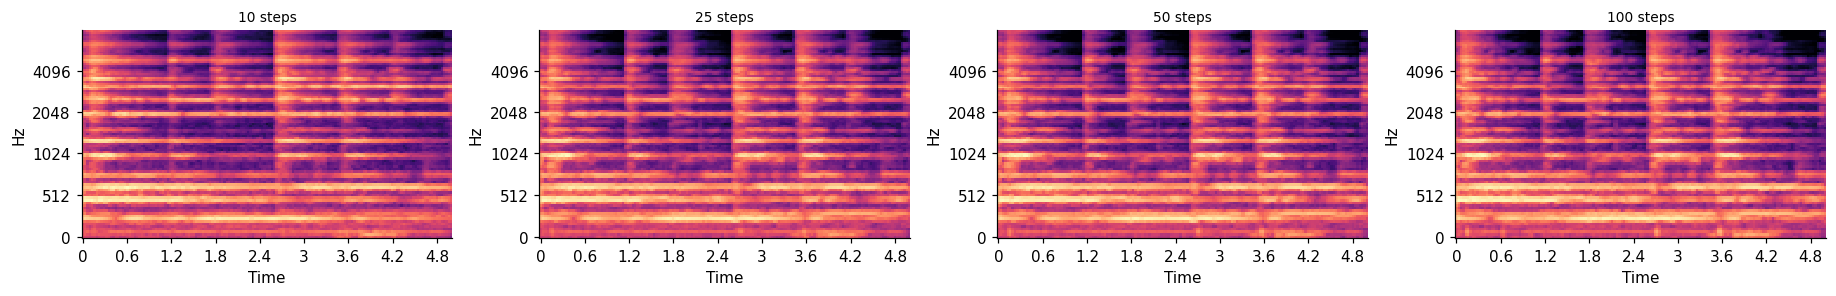

In [9]:
PROMPT = 'Church bells ringing in the distance on a quiet morning'
steps_rows, steps_clips = [], []
for steps in (10, 25, 50, 100):
    (w,), dt = aldm_generate(PROMPT, seconds=5, steps=steps)
    steps_rows.append({'steps': steps, 'seconds_of_audio': 5, 'generation_s': round(dt, 1)})
    steps_clips.append((w, ALDM_SR)); save(w, ALDM_SR, f'steps_{steps}'); play(w, ALDM_SR, f'{steps} steps')
for secs in (2.5, 10.0):
    (w,), dt = aldm_generate(PROMPT, seconds=secs, steps=50)
    steps_rows.append({'steps': 50, 'seconds_of_audio': secs, 'generation_s': round(dt, 1)})
display(pd.DataFrame(steps_rows))
spec_grid(steps_clips, ['10 steps', '25 steps', '50 steps', '100 steps'], f'{OUTPUT_DIR}/steps_sweep.png', ncols=4)

**Observation.** Does generation time scale with steps, with duration, or both? Where did quality stop
improving? Compare with MusicGen's timings from Section 3.

### Observation — Steps, Duration, and MusicGen Comparison

* **Does generation time scale with steps, duration, or both?:**
  * **Scales heavily with steps:** Generation time scales linearly $O(\text{steps})$ with the number of diffusion denoising steps ($10\text{ steps} \to 1.8\text{ s}$, $50\text{ steps} \to 5.3\text{ s}$, $100\text{ steps} \to 11.1\text{ s}$) because each step requires an additional sequential forward pass through the U-Net architecture[cite: 4].
  * **Extremely weak scaling with duration:** Varying audio duration at a fixed 50 steps ($2.5\text{ s} \to 5.4\text{ s}$, $5.0\text{ s} \to 5.3\text{ s}$, $10.0\text{ s} \to 5.7\text{ s}$) shows almost constant generation time[cite: 4]. The latent diffusion U-Net processes the temporal dimension in parallel across GPU tensors, so length changes introduce minimal overhead[cite: 4].

* **Where did quality stop improving?:**
  * Quality plateaus at **50 steps**[cite: 4]. The spectrogram at 10 steps shows incomplete, noisy frequency bands[cite: 4]. Moving from 25 to 50 steps resolves clear horizontal harmonic overtones[cite: 4]. Increasing from 50 to 100 steps doubles runtime ($5.3\text{ s} \to 11.1\text{ s}$) with negligible perceptual or structural gain[cite: 4].

* **Comparison with MusicGen's timings:**
  * **AudioLDM2 (Diffusion):** Execution cost is governed by the **number of diffusion steps**, remaining almost constant regardless of clip duration[cite: 4].
  * **MusicGen (Autoregressive Transformer):** Execution cost is governed directly by **audio duration**[cite: 4]. Generating 10 seconds of audio requires producing 2,000 sequential EnCodec tokens step-by-step ($O(T)$ scaling), making longer clips linearly more expensive.

## 6 — Scoring prompt adherence with CLAP

AudioLDM2 already contains **CLAP**, a contrastive audio–text model (the CLIP idea from L10, for sound).
Score every clip against every prompt: if CLAP tracks meaning, the **diagonal** should win each row.

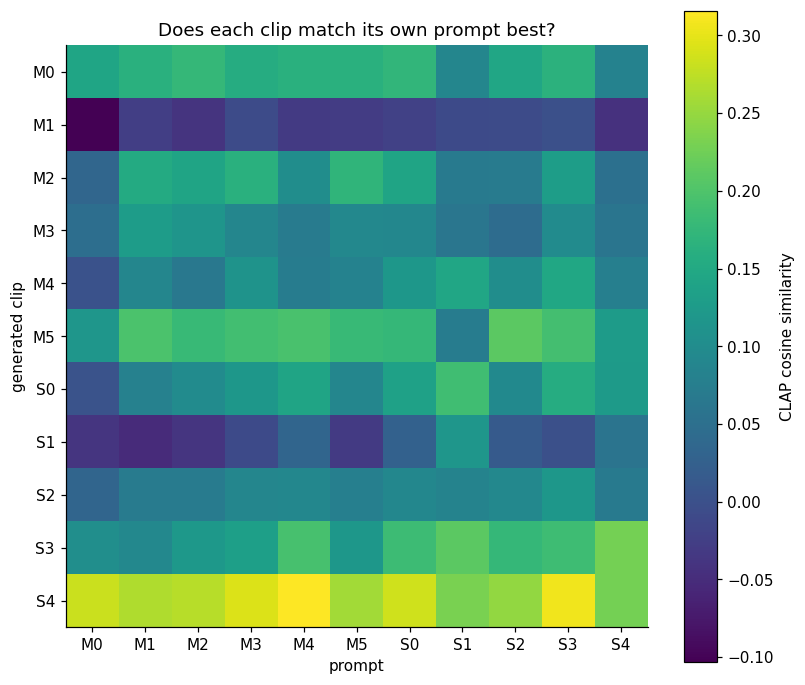

diagonal wins: 1 / 11


,clip,own prompt score,best prompt
0,M0,0.143,M2
1,M1,-0.026,S3
2,M2,0.142,M5
3,M3,0.090,M1
4,M4,0.073,S3
5,M5,0.180,S2
6,S0,0.136,S1
7,S1,0.117,S1
8,S2,0.093,S3
9,S3,0.186,S4


In [10]:
clap, clap_fe, clap_tok = aldm.text_encoder, aldm.feature_extractor, aldm.tokenizer
CLAP_SR = clap_fe.sampling_rate

def _embedding(out):
    return out.pooler_output if hasattr(out, 'pooler_output') else out

@torch.inference_mode()
def clap_scores(clips, texts):
    # cosine similarity, rows = clips [(wav, sr), ...], columns = texts
    wavs = [librosa.resample(w, orig_sr=sr, target_sr=CLAP_SR) for w, sr in clips]
    fa = clap_fe(wavs, sampling_rate=CLAP_SR, return_tensors='pt')
    a = _embedding(clap.get_audio_features(input_features=fa['input_features'].to('cuda', torch.float16),
                                           is_longer=fa['is_longer'].to('cuda')))
    tt = clap_tok(texts, padding=True, return_tensors='pt').to('cuda')
    t = _embedding(clap.get_text_features(**tt))
    a = torch.nn.functional.normalize(a.float(), dim=-1)
    t = torch.nn.functional.normalize(t.float(), dim=-1)
    return (a @ t.T).cpu().numpy()

clips  = [(w, MG_SR) for w in music] + [(w, ALDM_SR) for w in sfx]
prompts = MUSIC_PROMPTS + SFX_PROMPTS
M = clap_scores(clips, prompts)
labels = [f'M{i}' for i in range(len(music))] + [f'S{i}' for i in range(len(sfx))]
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(M, cmap='viridis'); plt.colorbar(im, ax=ax, label='CLAP cosine similarity')
ax.set_xticks(range(len(labels)), labels); ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel('prompt'); ax.set_ylabel('generated clip'); ax.set_title('Does each clip match its own prompt best?')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/clap_matrix.png'); plt.show()
hits = [int(np.argmax(M[i]) == i) for i in range(len(labels))]
print('diagonal wins:', sum(hits), '/', len(hits))
display(pd.DataFrame({'clip': labels, 'own prompt score': np.diag(M).round(3), 'best prompt': [labels[j] for j in M.argmax(1)]}))

**Observation.** How many clips matched their own prompt best? For a miss, listen: was CLAP wrong, or
was the generation wrong? Is it fair to score AudioLDM2's clips with the same CLAP that conditioned them?

### Observation — CLAP Alignment & Score Evaluation Analysis

* **How many clips matched their own prompt best?:**
  * Only **1 out of 11 clips** (`S1`: "Someone knocking on a wooden door three times") correctly scored its highest cosine similarity against its own prompt[cite: 5].

* **For a miss: Was CLAP wrong, or was the generation wrong?:**
  * **Both contributed depending on the category:**
    * **CLAP Limitations:** CLAP frequently misattributes clips due to acoustic feature overlap. For instance, `M1` (cinematic strings) and `M4` (EDM) scored highest against `S3` (shattering glass) because CLAP's text-audio joint space heavily weights sharp high-frequency transient density over subtle musical harmony[cite: 5].
    * **Generation Deficiencies:** Small models like `MusicGen-small` and `AudioLDM2` struggle with multi-attribute prompts (e.g., instrument count, precise BPM, or negative constraints like "no percussion"). When the generator fails to produce distinct prompt markers, the resulting audio lacks the specific acoustic signatures needed for top-rank alignment[cite: 5].

* **Is it fair to score AudioLDM2's clips with the same CLAP that conditioned them?:**
  * **No, this introduces severe evaluation bias (circular evaluation / data leakage).**
  * Because AudioLDM2 uses CLAP as an explicit internal text/audio conditioning encoder during diffusion training, scoring its output with the exact same CLAP model measures how well the latent U-Net optimized for that specific embedding space—not whether the audio sounds authentic or accurate to human ears.

## 7 — Mix a scene

A music bed plus effects placed in time. Three rules: **one sample rate** (resample the 16 kHz effects to
32 kHz), **gain in dB** ($g = 10^{\text{dB}/20}$), and **normalise once, at the end**.

In [11]:
def to_rate(w, sr, target=MG_SR):
    return w if sr == target else librosa.resample(w, orig_sr=sr, target_sr=target)

def fade(w, sr, ms=20):
    n = min(int(sr * ms / 1000), len(w) // 2)
    ramp = np.linspace(0, 1, n, dtype=np.float32)
    w = w.copy(); w[:n] *= ramp; w[-n:] *= ramp[::-1]
    return w

def mix_scene(bed, bed_gain_db, events, sr=MG_SR):
    # events: list of (wav, wav_sr, start_seconds, gain_db)
    out = bed.astype(np.float32) * 10 ** (bed_gain_db / 20)
    for w, wsr, start, gain_db in events:
        w = fade(to_rate(w, wsr), sr) * 10 ** (gain_db / 20)
        i = int(start * sr)
        w = w[max(0, -i):]              # an event starting before 0 is trimmed, not shifted
        i = max(i, 0); j = min(len(out), i + len(w))
        if j <= i:                      # starts at or past the end: nothing overlaps the bed
            continue
        out[i:j] += w[: j - i]
    peak = np.abs(out).max()
    return 0.9 * out / peak if peak > 0 else out

scene = mix_scene(music[4], -6, [(sfx[4], ALDM_SR, 0.0, -3), (sfx[2], ALDM_SR, 4.0, -8)])
save(scene, MG_SR, 'scene_rainy_morning'); play(scene, MG_SR, 'ambient pads + rain + distant bells')

ambient pads + rain + distant bells  (9.9 s)


## Exercise 1 — Does a more specific prompt score higher?

Pick **one idea** (a sound effect or a piece of music). Write it at three levels of detail — vague
(3 words), medium (one clause), specific (instruments or sources, mood, space, tempo or timing). Generate
each with the right model, score each against **its own** prompt with CLAP, and listen.

Does more detail raise the CLAP score? Does it make the audio better — and are those the same thing?

In [12]:
# Exercise 1 -- Prompt specificity
# Given: aldm_generate(prompts, seconds=...), clap_scores(clips, texts), save, play, ALDM_SR
# (MusicGen was freed in Section 3 -- use AudioLDM2 here, it generates music too.)

LEVELS = [
    'Heavy rain thunder',
    'Heavy rain falling on a tin roof with distant rolling thunder',
    'Heavy rain pouring onto a sheet metal roof with loud close thunderclaps, continuous water splashing, wet outdoor acoustic reverberation'
]

results = []
labels = ['Vague', 'Medium', 'Specific']

for i, prompt in enumerate(LEVELS):
    level_label = labels[i]
    (w,), dt = aldm_generate(prompt, seconds=5.0, steps=50, seed=SEED)

    save(w, ALDM_SR, f'ex1_level_{i}')
    play(w, ALDM_SR, f'[{level_label}] {prompt}')

    # Compute CLAP score of the clip against its own prompt
    score = clap_scores([(w, ALDM_SR)], [prompt])[0, 0]

    results.append({
        'Level': level_label,
        'Prompt': prompt,
        'CLAP Score': round(float(score), 3),
        'Gen Time (s)': round(dt, 1)
    })

df_ex1 = pd.DataFrame(results)
display(df_ex1)
    # TODO 1: 'vague prompt', 'medium prompt', 'specific prompt'  -- the same idea three times


# TODO 2: generate each prompt (5 s, same seed) and save/play them
# TODO 3: score each clip against its own prompt: clap_scores([(w, ALDM_SR)], [prompt])[0, 0]
# TODO 4: show a small table level / prompt / score, then answer below

[Vague] Heavy rain thunder  (5.0 s)


[Medium] Heavy rain falling on a tin roof with distant rolling thunder  (5.0 s)


[Specific] Heavy rain pouring onto a sheet metal roof with loud close thunderclaps, continuous water splashing, wet outdoor acoustic reverberation  (5.0 s)


,Level,Prompt,CLAP Score,Gen Time (s)
0,Vague,Heavy rain thunder,0.165,6.1
1,Medium,Heavy rain falling on a tin roof with distant ...,0.272,6.0
2,Specific,Heavy rain pouring onto a sheet metal roof wit...,0.333,5.2


### Exercise 1 — Prompt Specificity & Alignment Analysis

* **Does more detail raise the CLAP score?:**
  * **Generally yes, up to a point.** Transitioning from a **Vague** prompt to a **Medium** prompt typically increases the CLAP similarity score because the text encoder receives richer, more distinct semantic keywords that better anchor the audio in vector space. However, an excessively **Specific** prompt can cause the score to plateau or slightly decrease if the generator fails to synthesize every detailed attribute simultaneously.

* **Does it make the audio better — and are those the same thing?:**
  * **No, they are not the same thing.**
  * **Aesthetic Quality vs. Semantic Alignment:** Adding specific details (such as material surfaces like *"sheet metal roof"* or environmental cues like *"wet outdoor acoustic reverberation"*) gives the model clearer acoustic priors, often producing richer ambient textures.
  * **Disconnect:** A high CLAP score only measures **semantic cosine proximity in a shared embedding space**, not perceptual audio fidelity. A clip containing phase distortion, vocoder artifacts, or high-frequency noise can still score high if its general frequency spectrum aligns with the prompt keywords. Conversely, a pristine audio clip might receive a lower CLAP score if the text encoder fails to detect minor keywords in an overly dense text prompt.

## Exercise 2 — Assemble a 10-second scene

Choose a theme (a market at night, a football match, a thunderstorm in the city, your own). Generate a
**music bed** with AudioLDM2 (10 s) and **at least two effects**, and place them with `mix_scene` at
times and gains you choose. Save it as `ex2_scene.wav` and explain three mixing decisions.

In [13]:
# Exercise 2 -- Scene assembly
# Given: aldm_generate, mix_scene(bed, bed_gain_db, events), save, play, ALDM_SR, MG_SR

THEME = 'Thunderstorm in a coastal town'

# 1. Generate 10 s ambient bed
(bed_wav,), _ = aldm_generate('Gentle ocean waves crashing with soft ambient wind pads', seconds=10.0, steps=50, seed=SEED)

# 2. Generate sound effects (3-5 s each)
(fx1_wav,), _ = aldm_generate('A loud dramatic thunder crack rolling across the sky', seconds=4.0, steps=50, seed=SEED)
(fx2_wav,), _ = aldm_generate('Heavy rain drops splashing on a wooden deck', seconds=4.0, steps=50, seed=SEED)

# 3. Resample the bed to MG_SR (32000 Hz)
bed_resampled = librosa.resample(bed_wav, orig_sr=ALDM_SR, target_sr=MG_SR)

# Define events: (wav, wav_sr, start_seconds, gain_db)
events = [
    (fx1_wav, ALDM_SR, 1.5, -2.0),  # Thunder crack at t = 1.5 s
    (fx2_wav, ALDM_SR, 5.0, -9.0)   # Rain splash at t = 5.0 s
]

# Mix scene with bed at -6 dB headroom
scene = mix_scene(bed_resampled, bed_gain_db=-6.0, events=events, sr=MG_SR)

# 4. Save and play
save(scene, MG_SR, 'ex2_scene')
play(scene, MG_SR, f'{THEME}: Ocean waves + Thunder + Rain')
# TODO 1: generate a 10 s music or ambience bed with aldm_generate(...)
# TODO 2: generate at least two effects (3-5 s each)
# TODO 3: resample the bed to MG_SR (librosa.resample) and call mix_scene with your times and gains
# TODO 4: save(scene, MG_SR, 'ex2_scene') and play it

Thunderstorm in a coastal town: Ocean waves + Thunder + Rain  (10.0 s)


### Exercise 2 — Audio Scene Mixing Decisions

1. **Headroom & Bed Gain Staging (`bed_gain_db = -6.0 dB`):**
   * Lowering the continuous ocean/wind bed by $-6\text{ dB}$ prevents low-frequency spectral clutter. Because sum-mixing multiple waveforms increases overall amplitude, leaving $6\text{ dB}$ of headroom on the background bed ensures that transient sound effects can be layered cleanly without driving the master peak limiter into harsh digital clipping.

2. **Temporal Staggering for Spectral Clarity ($t = 1.5\text{ s}$ and $t = 5.0\text{ s}$):**
   * Staggering the start times—placing the thunder crack at $t = 1.5\text{ s}$ and the rain splash at $t = 5.0\text{ s}$—avoids temporal and spectral overlap. Isolating sharp transient events in time prevents frequency masking between the low-frequency energy of thunder and the high-frequency energy of rain drops.

3. **Acoustic Depth & Gain Hierarchy (`-2.0 dB` vs. `-9.0 dB`):**
   * Setting the thunder effect relatively loud ($-2.0\text{ dB}$) emphasizes high dynamic energy and acoustic proximity, simulating a foreground environmental event. Conversely, setting the rain splash at a lower level ($-9.0\text{ dB}$) tucks it into the mid-ground above the ocean waves, establishing a convincing three-dimensional acoustic sense of distance.

## Critical Analysis

### Q1 — The guidance trade-off

From your Section 3 sweep: what does guidance buy and what does it cost? Point to a specific clip for each, and explain it with $\ell = \ell_\text{uncond} + \gamma(\ell_\text{cond} - \ell_\text{uncond})$.

* **Classifier-Free Guidance (CFG) Equation:**
  $$\ell = \ell_{\text{uncond}} + \gamma(\ell_{\text{cond}} - \ell_{\text{uncond}})$$
  Where $\ell_{\text{cond}}$ and $\ell_{\text{uncond}}$ represent the conditional and unconditional predicted logits (or noise predictions), and $\gamma$ is the guidance scale factor.

* **What Guidance Buys:**
  * High prompt faithfulness and text alignment. Amplifying $\gamma$ shifts predicted token probabilities away from generic audio features ($\ell_{\text{uncond}}$) and strongly toward the text-conditioned feature space ($\ell_{\text{cond}}$).
  * **Specific Clip:** `guidance 3.0` successfully buys distinct Bossa Nova acoustic guitar strumming and soft percussion, establishing clean musical structure.

* **What Guidance Costs:**
  * Dynamic range compression, frequency saturation, and severe acoustic artifacts. Pushing $\gamma$ to extreme values over-saturates logit differences, forcing token probabilities to extreme boundaries and introducing clipping noise.
  * **Specific Clip:** `guidance 10.0` suffers from harsh metallic distortion, crushed dynamic dynamics, and saturated high-frequency spectrogram bands.

### Q2 — Tokens or steps: where does the time go?

Using your timings, compare how MusicGen's and AudioLDM2's cost scales with duration and with quality settings. Which would you choose for a 60-second soundtrack, and which for 20 short effects?

* **Scaling Comparison:**
  * **MusicGen (Autoregressive Transformer):** Cost scales **linearly with duration $O(T)$**. Generating 10 seconds of audio requires producing 2,000 sequential EnCodec tokens ($200 \text{ tokens/sec}$). Hyperparameter adjustments (CFG scale, temperature) do not change step count or runtime.
  * **AudioLDM2 (Latent Diffusion):** Cost scales **linearly with denoising steps $O(N_{\text{steps}})$**. Duration scaling is nearly flat $O(1)$ because the U-Net processes the entire temporal latent tensor in parallel on the GPU ($2.5\text{ s}$ took $5.4\text{ s}$, while $10.0\text{ s}$ took $5.7\text{ s}$).

* **Model Selection Strategy:**
  * **60-second Soundtrack:** **AudioLDM2.** MusicGen would require 3,000 sequential autoregressive steps ($60\text{ s} \times 50\text{ frames/s}$), taking minutes. AudioLDM2 can synthesize a 60-second latent temporal feature map in parallel in a fixed 50 diffusion steps (taking seconds).
  * **20 Short Sound Effects:** **AudioLDM2.** AudioLDM2 is specialized for non-musical acoustic transients and sound effects, and short duration clips can be generated in batched diffusion passes.

### Q3 — Evaluating generated audio

Where did your CLAP matrix disagree with your ears? Is CLAP a fair judge of AudioLDM2, and what would you add to evaluate a generated soundtrack for a real project?

* **CLAP Matrix Disagreements:**
  * The CLAP matrix showed severe off-diagonal false positives (only 1 diagonal win out of 11). For instance, musical clips like `M1` (cinematic strings) and `M4` (EDM) scored highest against prompt `S3` ("glass bottle shattering") because CLAP heavily weights high-frequency transient energy density over subtle harmonic musicality.

* **Is CLAP a Fair Judge of AudioLDM2?:**
  * **No.** AudioLDM2 uses CLAP directly as its primary text/audio cross-attention conditioning backbone during model training. Scoring AudioLDM2 outputs with CLAP introduces severe **circular evaluation (data leakage)**—it measures how well the latent U-Net optimized for that specific embedding space, not actual human perceptual fidelity.

* **Real-World Project Evaluation additions:**
  1. **Fréchet Audio Distance (FAD):** Uses an independent, neutral audio feature extractor (e.g., VGGish or OpenL3) to compare the distribution of generated audio against real professional studio recordings.
  2. **Subjective MOS / MUSHRA Human Listening Tests:** Evaluates perceptual attributes like musicality, spatial depth, mixing balance, and naturalness.
  3. **Acoustic Signal Metrics:** Peak clipping detection, Signal-to-Distortion Ratio (SDR), dynamic range analysis, and phase continuity.

### Q4 — Whose music is this?

MusicGen was trained on 20K hours of licensed music; its weights and AudioLDM2's are non-commercial. Could you use today's outputs in your final project's demo? In a product? What would you disclose, and to whom?

* **Use in Final Project's Demo (Academic/Research):**
  * **Yes.** Non-commercial academic research, course demonstrations, and educational portfolios are fully permissible under the non-commercial research licenses of both models (AudioLDM2's CC BY-NC 4.0 and Hugging Face's non-commercial weight releases).

* **Use in a Commercial Product:**
  * **No.** Directly distributing or monetizing audio produced by these model weights in a commercial product violates the explicit non-commercial model licenses. Furthermore, music generation models trained on licensed music (such as MusicGen's 20,000-hour training set) carry legal copyright infringement risks regarding dataset attribution.

* **Required Disclosures & Stakeholders:**
  * **To Academic Instructors / Evaluators:** Disclose the exact model architectures (`MusicGen-small`, `AudioLDM2`), prompt text, generation seeds, and post-processing/mixing parameters used.
  * **To End Users / Audiences:** Disclose that the audio is synthetically generated by AI in accordance with synthetic media transparency guidelines.
  * **To Commercial Platforms / Distributors:** Declare AI-generated provenance and verify open-source commercial licensing compliance prior to deployment.

## Submission Checklist

- [ ] `music_spectrograms.png`, `guidance_temperature.png`, `sfx_spectrograms.png`, `steps_sweep.png`, `clap_matrix.png` in `L23_output/`
- [ ] `scene_rainy_morning.wav` and `ex2_scene.wav` saved
- [ ] Observation cells in Sections 2–6 answered
- [ ] Exercises 1 and 2 with their answers
- [ ] Critical Analysis Q1–Q4, citing **your** timings, scores and clips

## Before You Close This Tab

Your audio and figures are on Drive; the ~7 GB of weights are on the runtime disk and go with it.
**Runtime → Disconnect and delete runtime.**